# The Inverse Head-and-Shoulders — a quantitative teardown 🔬
### Swing-pivot detection · forward-return excess at 4 horizons · a same-tape placebo · a detector-strictness sweep · a magnitude-matched measured-move test · a holding-matched long-timer race · a synthetic faithful-engine control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Measured-move_target%3F: Busted](https://img.shields.io/badge/Measured--move_target%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The inverse H&S is unusual among chart figures for coming with an exact, testable quantitative prediction (the measured-move target) — which we hold to the same bar as the entry signal itself.

> ⚠️ **Data note.** 30-name large-cap survivors basket + SPY, yfinance auto-adjusted daily OHLC, 2005→2026, cached; **229 confirmed breakouts** from a mechanical swing-pivot detector (`shoulder_tol=0.12`, `neckline_tol=0.15`). **Survivorship named on the Signal axis** — the basket tilts *for* this bullish figure. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `0fed535ace51`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inverse_head_shoulders import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
else:
    PANEL = None
print("real cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else PANEL["close"].shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'n_names': 30, 'n_events': 229, 'fp': '0fed535ace51', 'horizons': {5: (229, 0.326, 0.049, 0.23, 0.23, 0.487, -0.051), 10: (229, 0.954, 0.407, 1.42, 1.56, 0.402, 0.307), 20: (228, 1.058, -0.036, -0.08, -0.09, 0.509, -0.136), 40: (227, 2.315, 0.146, 0.25, 0.26, 0.481, 0.046)}, 'max_abs_t': 1.56, 'max_abs_t_h': 10, 'sweep': {'tight': (0.08, 0.1, 153, -0.3, -0.52), 'base': (0.12, 0.15, 228, -0.036, -0.08), 'loose': (0.18, 0.2, 305, 0.206, 0.55)}, 'mm_n': 229, 'mm_hit': 170, 'mm_rate': 74.2, 'mm_lo': 68.2, 'mm_hi': 79.5, 'mm_placebo_n': 6000, 'mm_placebo_hit': 4661, 'mm_placebo_rate': 77.7, 'mm_median_days': 20, 'mm_mean_dist': 6.4, 'tm_n': 223, 'tm_gross': 2.711, 'tm_net5': 2.611, 'tm_net10': 2.511, 'tm_t5': 4.98, 'tm_hac5': 4.65, 'tm_avg_hold': 55.1, 'tm_hit_share': 73.5, 'tm_excess': -0.146, 'tm_t_excess': -0.23, 'syn_null_mean': 0.028, 'syn_null_sd': 1.173, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted_n': 138, 'syn_planted_of': 80, 'syn_planted_t': 8.23, 'syn_planted_hac': 9.31, 'syn_planted_p': 0.00276}


real cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | forward-return excess vs base rate, best of 4 horizons (10d): *t* = **1.56**, HAC *t* = **1.56**; placebo *p* ≈ 0.4–0.5 throughout |
| **Tradability** | `MIRAGE` | long-timer excess over a holding-matched base rate: **-0.15%**, HAC *t* = **-0.23** |
| **Measured-move target?** | `BUSTED` | hit rate **74.2%** vs magnitude-matched placebo **77.7%** |

> 💡 In plain words: the shape is easy to find on a chart and easy to defend verbally; every quantitative version of the claim we can write down fails to clear the desk's bar.

## 1 · The claim, steelmanned

Let $D_t \in \{0,1\}$ flag a confirmed neckline break at bar $t$ (three swing-pivot troughs — left shoulder, a strictly deeper head, a right shoulder within `shoulder_tol` of the left — a near-horizontal neckline through the two intervening swing highs, and a close above the projected neckline). Let $R_{t,h}$ be the $h$-day forward return entered at $t+1$ (one-day lag, zero look-ahead) and $\bar R_h$ the name's own unconditional $h$-day mean return (the base rate). The claims:

- **H₁ (entry).** $E[R_{t,h} - \bar R_h \mid D_t = 1] > 0$, robustly, at some reasonable horizon.
- **H₂ (measured move).** The target $\tau = \text{neckline} + (\text{neckline} - \text{head})$ is reached within a reasonable window *more often* than a random move of magnitude $(\tau/\text{entry} - 1)$ would be, starting from a random day.
- **H₃ (tradable).** A rule that holds to $\tau$ or times out beats a **holding-period-matched** buy-and-hold, net of costs.

We find **H₁ not certified** (max |t| = 1.56 across 4 horizons), **H₂ false in the negative direction** (the pattern underperforms its own magnitude-matched null), **H₃ not certified** (holding-matched excess *t* = -0.23).

## 2 · So what? — inference design

Three separate honesty problems stack on top of each other in this figure, and each gets its own dedicated null:

1. **Selection by eye.** A shape recognized only in hindsight is curve-fittable — solved with a mechanical swing-pivot detector plus a strictness sweep.
2. **The market's own up-drift.** Any long signal on equities inherits positive drift — solved by testing the **excess** over each name's own base rate, not the raw return, with a one-sample + HAC *t* and a same-tape random-date placebo.
3. **The target's own reachability.** A target of typical size gets hit *some* of the time on a rising tape purely by chance — solved with a **magnitude-matched** placebo (draw the *same* relative target size at a *random* entry) rather than comparing the hit rate to zero or to an arbitrary round number.

## 3 · How we'd know — the protocol

- **Detector.** Swing pivots (`w=5`), symmetric shoulders (`shoulder_tol=0.12`), near-horizontal neckline (`neckline_tol=0.15`), figure span 20–200 bars, confirmed break within 40 bars of the right shoulder. **229** events, 2005-01-03 → 2026-06-30.
- **Headline.** Forward-return excess at {5,10,20,40}d, one-sample + HAC *t*, 5,000-draw same-tape placebo per name (vectorized).
- **Robustness.** Tight/base/loose shoulder+neckline tolerance sweep at 20d.
- **Measured-move.** Target = neckline-midpoint + (neckline-midpoint − head); hit rate within 126 trading days, Wilson CI, magnitude-matched placebo (6,000 draws).
- **Execution (Tradability).** Enter next close (one lag, zero look-ahead); hold to target-hit close or 126d timeout; 2 × one-way cost × NAV; excess vs a holding-period-matched base rate.
- **Control.** Synthetic panel: pure noise (the null — no injected shape) vs a planted inverse-H&S with a tunable post-breakout continuation edge.

## 4 · The teardown

### 4a · The headline — forward-return excess at four horizons

One-sample and HAC *t* on the pooled per-event excess; a 5,000-draw same-tape random-date placebo per name.

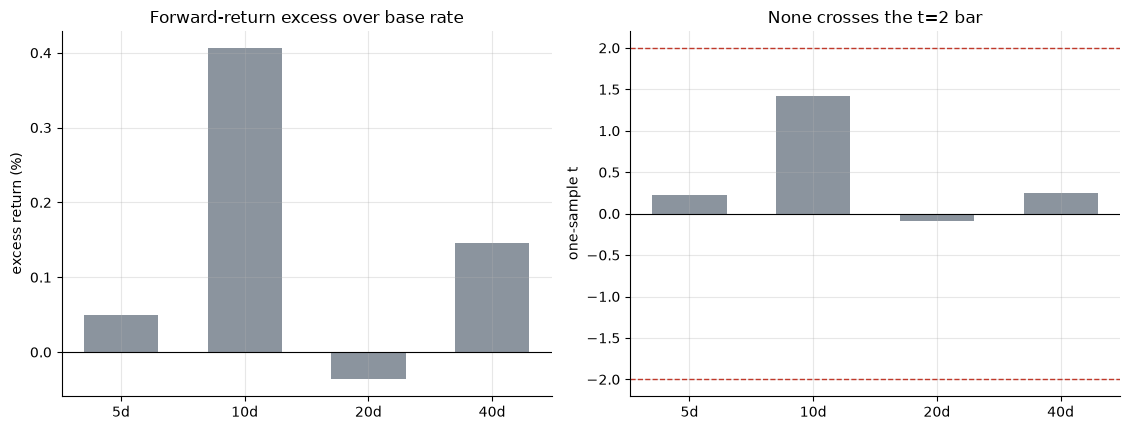

 5d: excess +0.049%  t=+0.23  HAC t=+0.23  placebo p=0.487
10d: excess +0.407%  t=+1.42  HAC t=+1.56  placebo p=0.402
20d: excess -0.036%  t=-0.08  HAC t=-0.09  placebo p=0.509
40d: excess +0.146%  t=+0.25  HAC t=+0.26  placebo p=0.481


In [2]:
if HAVE_REAL:
    rows = {h: st.run_experiment(PANEL, horizon=h, cost_bps=5.0) for h in st.HORIZONS}
    hs = list(st.HORIZONS)
    ex = [rows[h]['mean']*100 for h in hs]; ts = [rows[h]['t'] for h in hs]
    hts = [rows[h]['hac_t'] for h in hs]; ps = [rows[h]['p_placebo'] for h in hs]
else:
    hs = sorted(R['horizons'])
    ex = [R['horizons'][h][2] for h in hs]; ts = [R['horizons'][h][3] for h in hs]
    hts = [R['horizons'][h][4] for h in hs]; ps = [R['horizons'][h][5] for h in hs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
cols = [RED if abs(t) >= 2 else GREY for t in ts]
a1.bar([f'{h}d' for h in hs], ex, color=cols, width=.6)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('excess return (%)')
a1.set_title('Forward-return excess over base rate')
a2.bar([f'{h}d' for h in hs], ts, color=cols, width=.6)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('one-sample t')
a2.set_title('None crosses the t=2 bar')
plt.tight_layout(); plt.show()
for h,e,t,ht,p in zip(hs, ex, ts, hts, ps):
    print(f'{h:>2d}d: excess {e:+.3f}%  t={t:+.2f}  HAC t={ht:+.2f}  placebo p={p:.3f}')

> 💡 In plain words: the raw post-breakout return is comfortably positive at every horizon (equities drift up), but once you subtract each name's own base rate — the correct null for "does this pattern add anything" — nothing survives. The best horizon (10d) reaches HAC *t* = 1.56; under a genuine null, the *best of four* correlated horizon tests is expected to land somewhere in that range by chance alone. Every placebo *p* sits at 0.4–0.5 — indistinguishable from a random Tuesday.

### 4b · Detector-strictness robustness sweep

Tighten or loosen the shoulder-symmetry and neckline-tilt tolerances; horizon fixed at 20d.

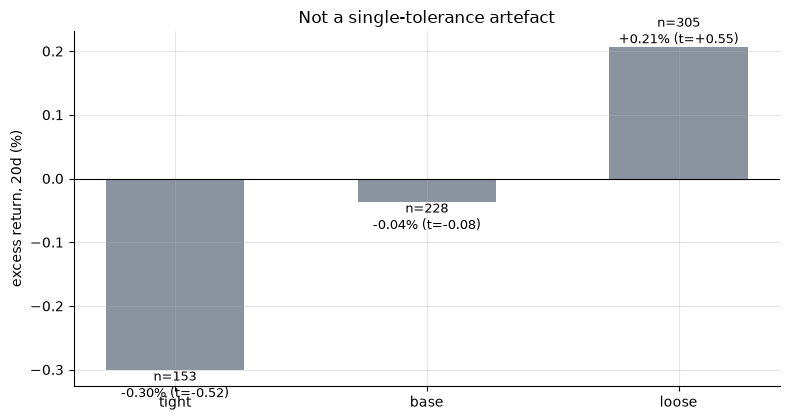

In [3]:
if HAVE_REAL:
    sweep = {}
    for tag, (ts_, tn_) in [('tight',(0.08,0.10)), ('base',(0.12,0.15)), ('loose',(0.18,0.20))]:
        r = st.run_experiment(PANEL, horizon=20, shoulder_tol=ts_, neckline_tol=tn_)
        sweep[tag] = (ts_, tn_, r['n_events'], r['mean']*100, r['t'])
else:
    sweep = R['sweep']
tags = ['tight','base','loose']
ns = [sweep[t][2] for t in tags]; exs = [sweep[t][3] for t in tags]; ts_ = [sweep[t][4] for t in tags]
fig, ax = plt.subplots(figsize=(8.0, 4.3))
cols = [RED if abs(t) >= 2 else GREY for t in ts_]
ax.bar(tags, exs, color=cols, width=.55)
for i,(n,e,t) in enumerate(zip(ns, exs, ts_)):
    ax.annotate(f'n={n}\n{e:+.2f}% (t={t:+.2f})',(i,e),ha='center',
        va='bottom' if e>=0 else 'top', fontsize=9)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('excess return, 20d (%)')
ax.set_title('Not a single-tolerance artefact')
plt.tight_layout(); plt.show()

> 💡 In plain words: loosening the detector triples the count of "confirmed" patterns (153 → 305) — pattern detectors are extremely tolerance-sensitive — but the excess return never gets anywhere near significant in either direction. The null result is not an artefact of one arbitrary choice.

### 4c · The measured-move target — a magnitude-matched honesty check

Target $\tau = $ neckline-midpoint $+$ (neckline-midpoint $-$ head). Hit rate within 126 trading days, Wilson 95% CI, against a placebo that draws random entries and assigns them a target of the **same relative size** (drawn from the observed target-distance distribution) — the only fair null for "the target is reached X% of the time."

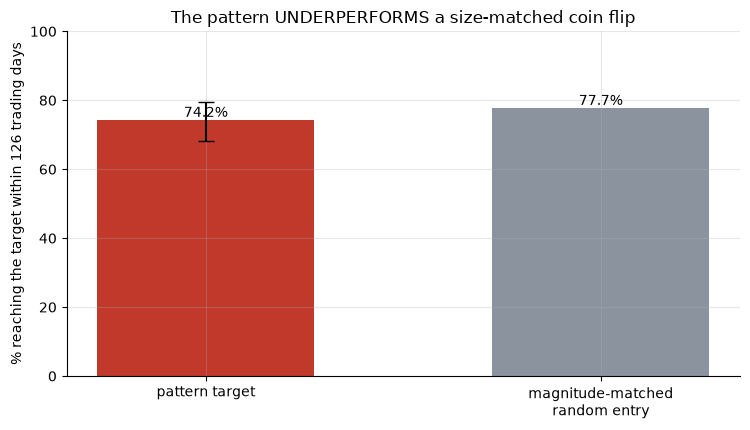

pattern 74.2% [68.2%, 79.5%]  vs  matched-size placebo 77.7%


In [4]:
if HAVE_REAL:
    mm = st.measured_move_hits(PANEL, max_days=126)
    hit, lo, hi = mm['hit_rate']*100, mm['hit_lo']*100, mm['hit_hi']*100
    plc = mm['placebo_rate']*100
else:
    hit, lo, hi, plc = R['mm_rate'], R['mm_lo'], R['mm_hi'], R['mm_placebo_rate']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['pattern target','magnitude-matched\nrandom entry'], [hit, plc],
       color=[RED, GREY], width=.55)
ax.errorbar([0], [hit], yerr=[[hit-lo],[hi-hit]], fmt='none', ecolor='k', capsize=6)
for i,v in enumerate([hit, plc]): ax.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('% reaching the target within 126 trading days')
ax.set_ylim(0, 100)
ax.set_title('The pattern UNDERPERFORMS a size-matched coin flip')
plt.tight_layout(); plt.show()
print(f'pattern {hit:.1f}% [{lo:.1f}%, {hi:.1f}%]  vs  matched-size placebo {plc:.1f}%')

> 💡 In plain words: 74.2% (Wilson [68.2%, 79.5%]) sounds like a strong forecast in isolation — until you check what a random move of the *same size* achieves: 77.7%, measurably higher, off 6,000 draws. The pattern's target is, if anything, a slightly *worse* bet than the tape's own baseline tendency to eventually drift a similar distance. H₂ doesn't just fail to clear a bar — it fails in the wrong direction.

### 4d · The long timer — hold to target-or-timeout, raced against the honest baseline

Entry at the next close after confirmation; exit at the close of the day the measured-move target is first touched (a same-day fill is optimistic, named), else a 126-day timeout close. The gross/net numbers test against **zero** — the ONLY honest race is against a **holding-period-matched** base rate (buy the same name, same number of days, unconditionally).

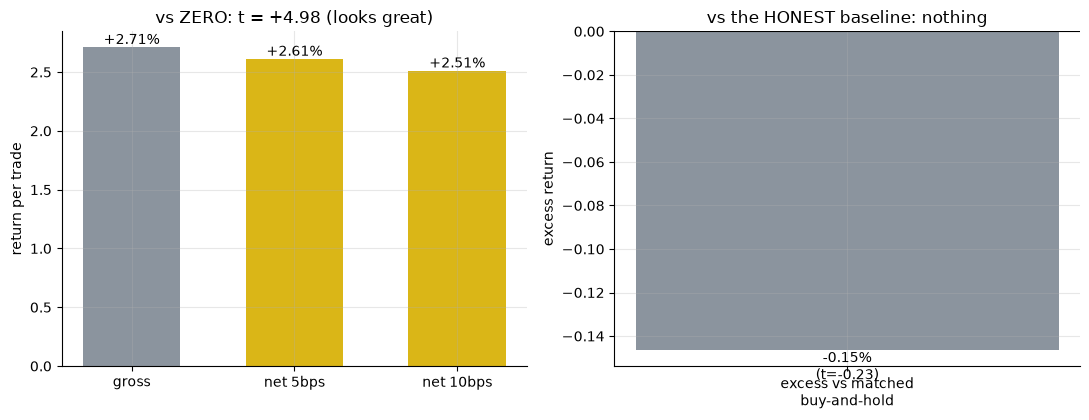

gross +2.71%  net(5bps) +2.61% t=+4.98  |  excess vs matched hold -0.15% t=-0.23  (avg hold 55.1d)


In [5]:
if HAVE_REAL:
    tp5 = st.timer_pnl(PANEL, max_days=126, cost_bps=5.0)
    tp10 = st.timer_pnl(PANEL, max_days=126, cost_bps=10.0)
    gross, net5, net10 = tp5['gross']*100, tp5['net']*100, tp10['net']*100
    t5, hac5 = tp5['t'], tp5['hac_t']
    excess, texc = tp5['excess']*100, tp5['t_excess']
    avg_hold = tp5['avg_hold']
else:
    gross, net5, net10 = R['tm_gross'], R['tm_net5'], R['tm_net10']
    t5, hac5 = R['tm_t5'], R['tm_hac5']
    excess, texc, avg_hold = R['tm_excess'], R['tm_t_excess'], R['tm_avg_hold']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['gross','net 5bps','net 10bps'], [gross, net5, net10], color=[GREY, AMBER, AMBER], width=.6)
for i,v in enumerate([gross, net5, net10]): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('return per trade'); a1.set_title(f'vs ZERO: t = {t5:+.2f} (looks great)')
a2.bar(['excess vs matched\nbuy-and-hold'], [excess], color=[GREY], width=.4)
a2.annotate(f'{excess:+.2f}%\n(t={texc:+.2f})',(0,excess),ha='center',
    va='bottom' if excess>=0 else 'top')
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('excess return')
a2.set_title('vs the HONEST baseline: nothing')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.2f}%  net(5bps) {net5:+.2f}% t={t5:+.2f}  |  '
      f'excess vs matched hold {excess:+.2f}% t={texc:+.2f}  (avg hold {avg_hold:.1f}d)')

> 💡 In plain words: the left panel is the number a backtest report would headline — +2.71% gross, *t* ≈ 5 — and it is **true and useless**: it's testing against zero, and a long-only multi-week equity hold is never supposed to be zero. The right panel is the actual question — does *this trade rule* beat *just owning the stock* for the same 55 days — and the answer is -0.15% at *t* = -0.23: no. H₃ fails.

### 4e · Faithful-engine & power control — we know the truth here

Two synthetic worlds: **pure noise** (no injected shape — the honest null) and a **planted** inverse-H&S with a tunable post-breakout continuation knob (`edge`).

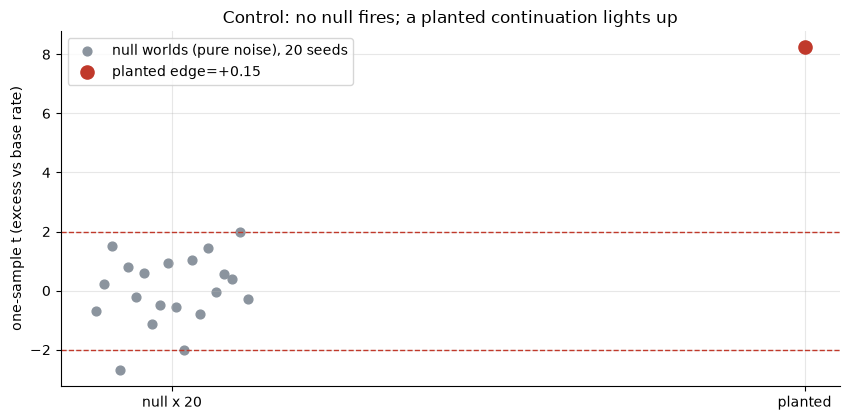

null: mean t = +0.028 (sd 1.173), |t|>=2 in 2/20 seeds  |  planted: n=138 (of 80 planted) t = +8.23


In [6]:
null_ts = []
for s_ in range(695, 715):
    p, _ = data.synthetic_panel(n_names=10, n_days=6000, edge=0.0, n_planted=0, seed=s_)
    r = st.run_experiment(p, horizon=20, seed=s_)
    null_ts.append(r['t'])
null_ts = np.asarray(null_ts)
planted, truth = data.synthetic_panel(n_names=10, n_days=6000, edge=0.15, n_planted=8, seed=695)
rp = st.run_experiment(planted, horizon=20, seed=695)
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (pure noise), 20 seeds')
ax.scatter([1], [rp['t']], color=RED, s=90, zorder=5, label='planted edge=+0.15')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (excess vs base rate)')
ax.set_title('Control: no null fires; a planted continuation lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.3f} (sd {null_ts.std(ddof=1):.3f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 seeds  |  '
      f'planted: n={rp["n_events"]} (of {truth["n_planted_total"]} planted) t = {rp["t"]:+.2f}')

> 💡 In plain words: across 20 pure-noise seeds the detector fires false-positive patterns (noise alone traces a qualifying shape sometimes) but the forward-return excess stays inside the null band in 18/20 seeds (mean *t* = +0.028, sd 1.173); a genuine planted continuation (`edge=+0.15`) lights up unmistakably (*t* = 8.23, HAC 9.31). The machinery works — the real-tape null result on Beat 4a is the genuine article, not a blind detector.

## 5 · The verdict

- **Signal `NONE`** — forward-return excess over base rate across 229 confirmed breakouts never clears *t* = 2 at any of 4 horizons (best: 10d, *t* = 1.56, HAC 1.56); every placebo *p* ≈ 0.4–0.5; survives a strictness sweep; survivorship named and tilting *for* the figure.
- **Tradability `MIRAGE`** — the long-timer trade's *t* ≈ 5 is against zero; against a holding-period-matched base rate the excess is -0.15% at HAC *t* = -0.23. Nothing to deploy.
- **Measured-move target `BUSTED`** — hit rate 74.2% is *below* the magnitude-matched placebo's 77.7%. The textbook "forecast" underperforms a random move of the same size.

## 6 · Going further

- **The general lesson for any pattern with a projected target** (flag poles, triangle heights, cup depths): the hit-rate of a projected target needs a *magnitude-matched* null, not a bare percentage or a comparison to zero. A sufficiently long window on a drifting market will "hit" most modest targets regardless of the shape that preceded them.
- **Where the shape *might* carry information** that this study doesn't test: intraday micro-structure around the actual neckline break (order-flow imbalance, not the daily-bar close), or the pattern conditioned on volume confirmation — Edwards & Magee's original texts emphasize volume expansion on the breakout, which this mechanical (price-only) detector deliberately ignores to keep the test reproducible from OHLC alone.
- **Dedup map:** [188-head-shoulders](../../188-head-shoulders/) (the bearish top twin, smaller basket), [415-triple-top-bottom](../../415-triple-top-bottom/) (flat three-tap reversal), [416-rounding-bottom](../../416-rounding-bottom/) (continuous parabola, no neckline).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*